## Different ways to make DAGs

we have tried the adjacency matrix way to make the DAG for gen data (1000) samples

Importing the required packages

In [1239]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from dowhy import CausalModel
from castle.algorithms import PC
from castle.common import GraphDAG

Making a dataframe with the gen data

In [1240]:
df = pd.read_csv ("gen_data_1000.csv")

Using PC algorithm to make a causal matrix

Note:- We are trying to manipulate the value of alpha here. Any value between 0-0.2 gives us this DAG (this is quite close to the original one; only B and outcome missing). The moment it goes above 0.2 it becomes a complex DAG with various uncessary relationships. 


In [1241]:
alpha= 1.0
pc = PC(alpha=alpha)

pc.learn(df)

In [1242]:
pc.causal_matrix

Tensor([[0, 1, 1, 1, 1, 1, 1],
        [1, 0, 1, 1, 1, 1, 1],
        [1, 1, 0, 1, 1, 1, 1],
        [1, 1, 1, 0, 1, 1, 1],
        [1, 1, 1, 1, 0, 1, 1],
        [1, 1, 1, 1, 1, 0, 1],
        [1, 1, 1, 1, 1, 1, 0]])

Making a GraphDAG

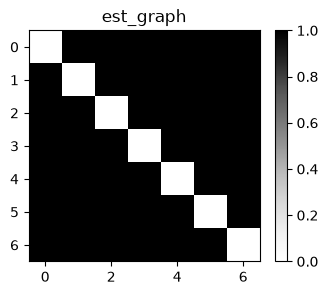

In [1243]:
GraphDAG(est_dag=pc.causal_matrix)

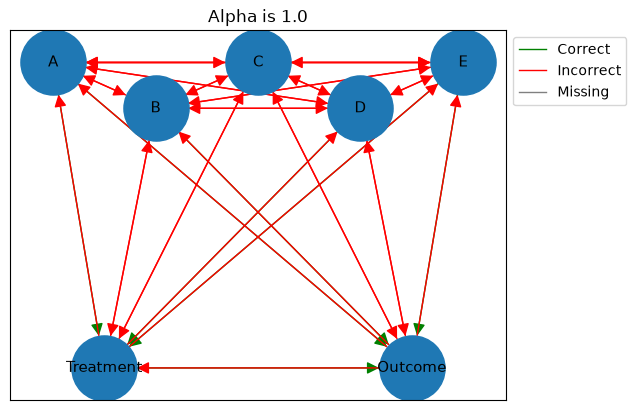

In [1244]:
adj_matrix= np.array(pc.causal_matrix)

node_names=["A","B","C","D","E","Treatment","Outcome"]

G=nx.from_numpy_array(adj_matrix, create_using=nx.DiGraph)

mapping={i:node_names[i] for i in range(len(node_names))}
G=nx.relabel_nodes(G, mapping)

pos={
    "A":(1,1),
    "B":(2,0.85),
    "C":(3,1),
    "D":(4,0.85),
    "E":(5,1),
    "Treatment":(1.5,0),
    "Outcome":(4.5,0)
}

gen_list=list(G.edges())
true_list=list(G_true.edges())

G_full=gen_list

list_of_colors=[]
line_style=[]

for a in gen_list:
    if a in true_list:
        edgecolor="Green"
        style="-"
    else:
        edgecolor="Red"
        style="-"
    list_of_colors.append(edgecolor)
    line_style.append(style)

for b in true_list:
    if b not in gen_list:
        edgecolor="Grey"
        style=":"
        list_of_colors.append(edgecolor)
        line_style.append(style)
        G_full.append(b)

from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], color='green', lw=1, label='Correct'),
    Line2D([0], [0], color='red', lw=1, label='Incorrect'),
    Line2D([0], [0], color='grey', lw=1, label='Missing'),
]

fig, ax = plt.subplots()
ax.legend(handles=legend_elements, bbox_to_anchor=[1,1],loc="upper left")

nx.draw_networkx(
    G,
    pos,
    with_labels=True,
    arrows=True,
    edgelist=G_full,
    edge_color=list_of_colors,
    style=line_style,
    node_size=2200,
    font_size=11,
    arrowsize=18
)

plt.title(f"Alpha is {alpha}")
plt.savefig(f"{alpha}.png",bbox_inches="tight")
plt.show()

Making a DAG using the utils file

In [1245]:
import utils_causal

nodes = ['A', 'B', 'C', 'D', 'E', 'outcome', 'treatment']
labels = nodes

nodes_labels = [(n, n) for n in nodes]

edges = []
for i, start_node in enumerate(nodes):
    for j, end_node in enumerate(nodes):
        if pc.causal_matrix[i, j] == 1:
            edges.append((start_node, end_node))

2026-08-03 12:15:30,901 - c:\Users\gk442\AppData\Local\miniconda3\envs\causal\Lib\site-packages\dowhy\causal_model.py[line:506] - INFO: Model to find the causal effect of treatment ['Treatment'] on outcome ['Outcome']
2026-08-03 12:15:30,903 - c:\Users\gk442\AppData\Local\miniconda3\envs\causal\Lib\site-packages\dowhy\utils\plotting.py[line:84] - INFO: Pygraphviz installation not found, falling back to networkx plotting. For better looking plots, consider installing pygraphviz. Note This requires both the Python pygraphviz package (``pip install pygraphviz``) and the shared system library (e.g. ``brew install graphviz`` or ``apt-get install graphviz``)


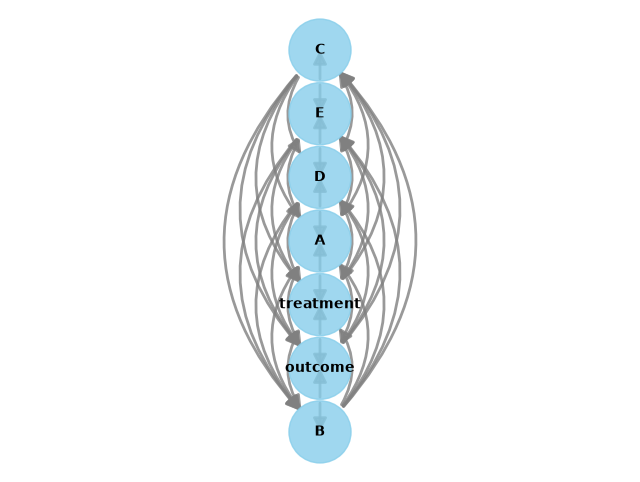

In [1246]:
model_test = utils_causal.make_causalmodel_object(nodes_labels, edges)
model_test.view_model()

Trying to make DAG with a adjacency matrix
(This lets us define the relationships individually and also lets us choose position of the nodes)

Note: This is the right answer

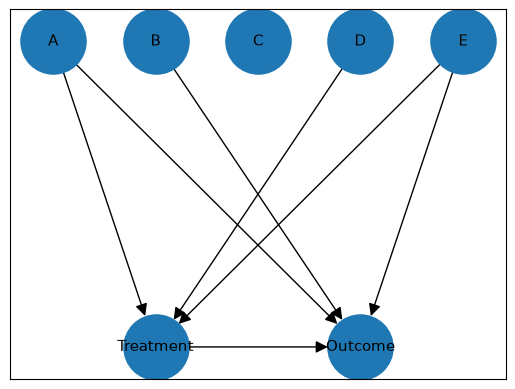

In [1247]:
adj_matrix= np.array([
    [0, 0, 0, 0, 0, 1, 1],
    [0, 0, 0, 0, 0, 0, 1],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 0],
    [0, 0, 0, 0, 0, 1, 1],
    [0, 0, 0, 0, 0, 0, 1],
    [0, 0, 0, 0, 0, 0, 0]
])

node_names=["A","B","C","D","E","Treatment","Outcome"]

G_true=nx.from_numpy_array(adj_matrix, create_using=nx.DiGraph)

mapping={i:node_names[i] for i in range(len(node_names))}
G_true=nx.relabel_nodes(G_true, mapping)

pos={
    "A":(1,1),
    "B":(2,1),
    "C":(3,1),
    "D":(4,1),
    "E":(5,1),
    "Treatment":(2,0),
    "Outcome":(4,0)
}

nx.draw_networkx(
    G_true,
    pos,
    with_labels=True,
    arrows=True,
    node_size=2200,
    font_size=11,
    arrowsize=18
)

Making the DAG with a more manual approach

In [1248]:
gml_graph= """
graph[
    directed 1

    node[
    id "A"
    label "A"
    ]

    node[
    id "B"
    label "B"
    ]

    node[
    id "C"
    label "C"
    ]

    node[
    id "D"
    label "D"
    ]

    node[
    id "E"
    label "E"
    ]    

    node[
    id "T"
    label "Treatment"
    ]  

    node[
    id "O"
    label "Outcome"
    ]  

    edge[
    source "A"
    target "T"
    ]

    edge[
    source "A"
    target "O"
    ]

    edge[
    source "B"
    target "O"
    ]

    edge[
    source "D"
    target "T"
    ]

    edge[
    source "E"
    target "T"
    ]

    edge[
    source "E"
    target "O"
    ]

    edge[
    source "T"
    target "O"
    ]
]
"""


In [1249]:

model=CausalModel(
    data=df,
    treatment="X",
    outcome="Y",
    graph=gml_graph
)

2026-08-03 12:15:31,536 - c:\Users\gk442\AppData\Local\miniconda3\envs\causal\Lib\site-packages\dowhy\causal_model.py[line:506] - INFO: Model to find the causal effect of treatment ['X'] on outcome ['Y']
c:\Users\gk442\AppData\Local\miniconda3\envs\causal\Lib\site-packages\dowhy\causal_model.py:583: UserWarning: 2 variables are assumed unobserved because they are not in the dataset. Configure the logging level to `logging.WARNING` or higher for additional details.
  warnings.warn(
2026-08-03 12:15:31,539 - c:\Users\gk442\AppData\Local\miniconda3\envs\causal\Lib\site-packages\dowhy\causal_model.py[line:588] - WARNING: The graph defines 7 variables. 5 were found in the dataset and will be analyzed as observed variables. 2 were not found in the dataset and will be analyzed as unobserved variables. The observed variables are: '['A', 'B', 'C', 'D', 'E']'. The unobserved variables are: '['Outcome', 'Treatment']'. If this matches your expectations for observations, please continue. If you exp

2026-08-03 12:15:31,550 - c:\Users\gk442\AppData\Local\miniconda3\envs\causal\Lib\site-packages\dowhy\utils\plotting.py[line:84] - INFO: Pygraphviz installation not found, falling back to networkx plotting. For better looking plots, consider installing pygraphviz. Note This requires both the Python pygraphviz package (``pip install pygraphviz``) and the shared system library (e.g. ``brew install graphviz`` or ``apt-get install graphviz``)


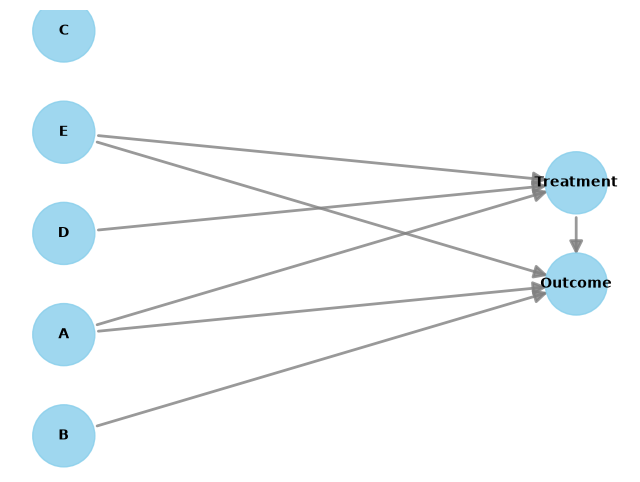

In [1250]:
model.view_model()